### 10x file preprocessing

This notebook was used to create the 10x dataset used in tutorial 03_training_prediciton. Initial files can be downloaded from the 10x website (https://www.10xgenomics.com/resources/datasets under and the keywords "a new way immune profiling"). It is also an updated form of a notebook from our reproducibility repository of which the resulting dataset was used for the publication (https://github.com/SchubertLab/mvTCR_reproducibility/blob/master/preprocessing/10x_preprocessing.ipynb)

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import os 
import numpy as np
import scipy as sci
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as pl

import scanpy as sc
import scirpy as ir
import anndata as ann
import awkward as ak

from scipy.sparse import csr_matrix
from matplotlib import rcParams
from matplotlib import colors

e:\Anaconda\envs\mvTCR\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\Anaconda\envs\mvTCR\lib\site-packages\airr\schema.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream


In [2]:
path_base = r"E:\Python code\Machine learning\JupyterNote\Bio_CRC\Data\EAE\GSE188320\\"
path_avidity = path_base + '10x_processed.h5ad'

In [3]:
import muon as mu
# mdata = mu.read("/ihome/ylee/yiz133/Code/Data processing/all_Common_DEtop2500.h5mu")

mdata = mu.read(path_base + "GSE188320_batch6_9_gex_tcr_mvTCR.h5mu")
mdata

e:\Anaconda\envs\mvTCR\lib\site-packages\anndata\_core\anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
e:\Anaconda\envs\mvTCR\lib\site-packages\anndata\utils.py:334: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)


MuData object with n_obs × n_vars = 39845 × 27998
  2 modalities
    gex:	39845 x 27998
      obs:	'batch', 'condition', 'mouse_id', 'assignment_demuxem'
    airr:	39845 x 0
      obsm:	'airr'

In [4]:
mdata['gex'].obs['condition']

AAACCTGAGAGTCGGT-1-b6m1    EAE
AAACCTGAGGCTCAGA-1-b6m1    EAE
AAACCTGCAATAGCAA-1-b6m1    EAE
AAACCTGCAGTCTTCC-1-b6m1    EAE
AAACCTGCATTCTTAC-1-b6m1    EAE
                          ... 
TTTGGTTTCGCTTAGA-1-b9m2     UT
TTTGTCAAGTATCTCG-1-b9m2     UT
TTTGTCAGTCGCATCG-1-b9m2     UT
TTTGTCAGTTTGTGTG-1-b9m2     UT
TTTGTCATCCTGCTTG-1-b9m2     UT
Name: condition, Length: 39845, dtype: category
Categories (2, object): ['EAE', 'UT']

In [5]:
adata = mdata['gex']
adata.obsm['airr'] = mdata.mod['airr'].obsm['airr']

adata.obs['mouse_id'].value_counts()

mouse_id
mouse1    20051
mouse2    19794
Name: count, dtype: int64

In [6]:
adata.obs['n_counts'] = adata.X.sum(1)
adata.obs['log_counts'] = np.log10(adata.obs['n_counts'])

adata.obs['n_genes'] = (adata.X > 0).sum(1)

mt_gene_mask = [gene.startswith('MT-') for gene in adata.var_names]
mt_gene_index = np.where(mt_gene_mask)[0]
adata.obs['mt_fraction'] = adata.X[:, mt_gene_index].sum(1) / adata.X.sum(1)

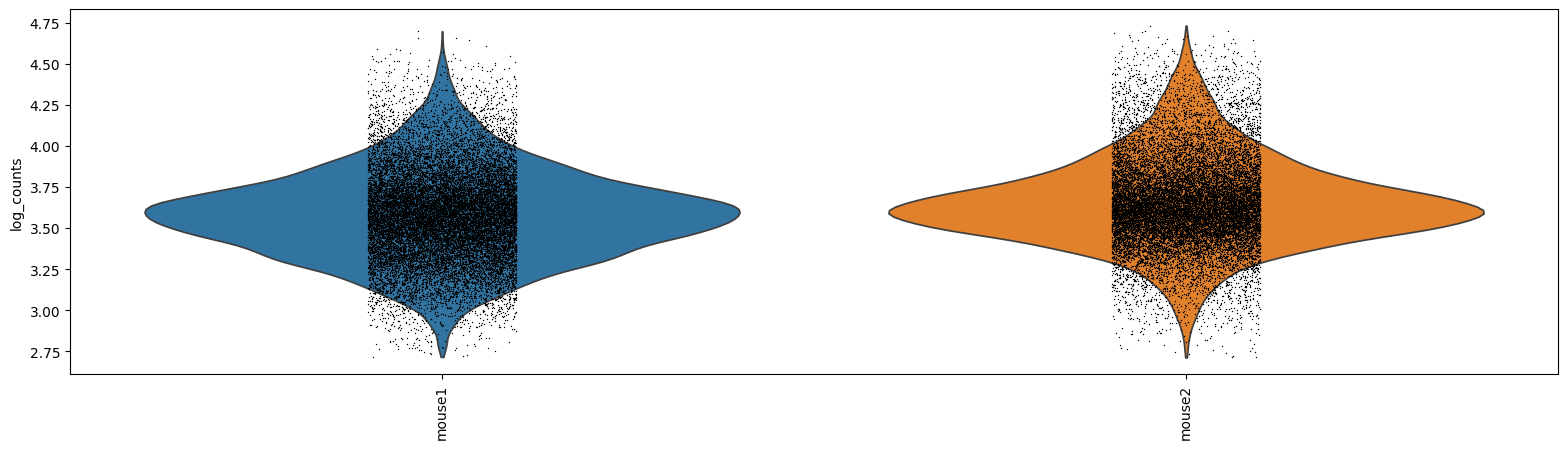

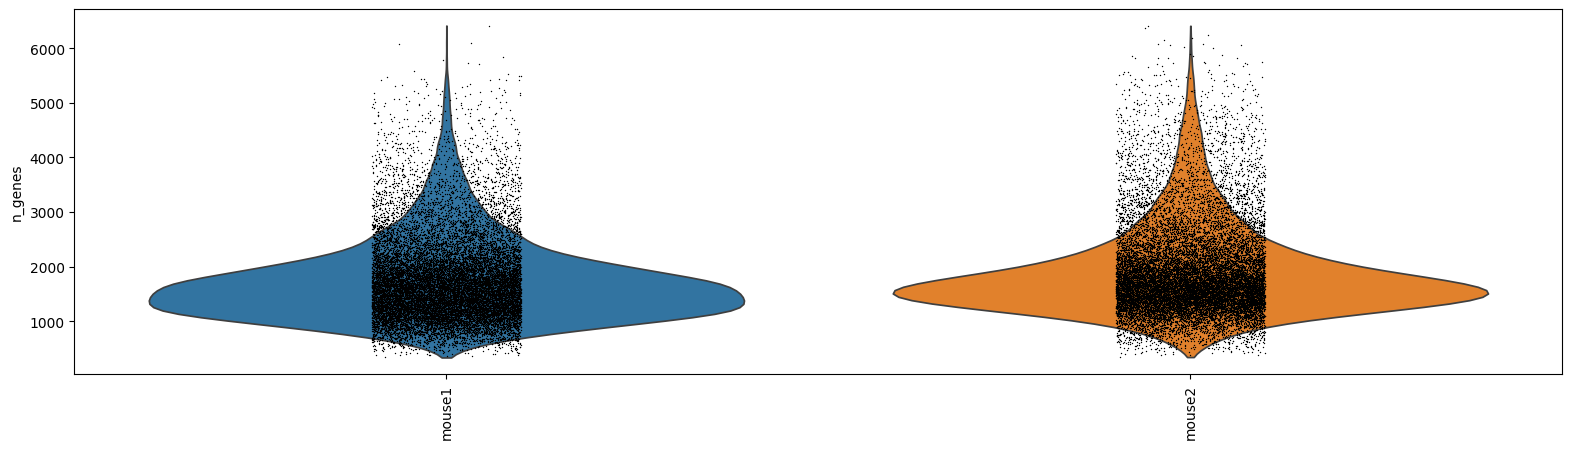

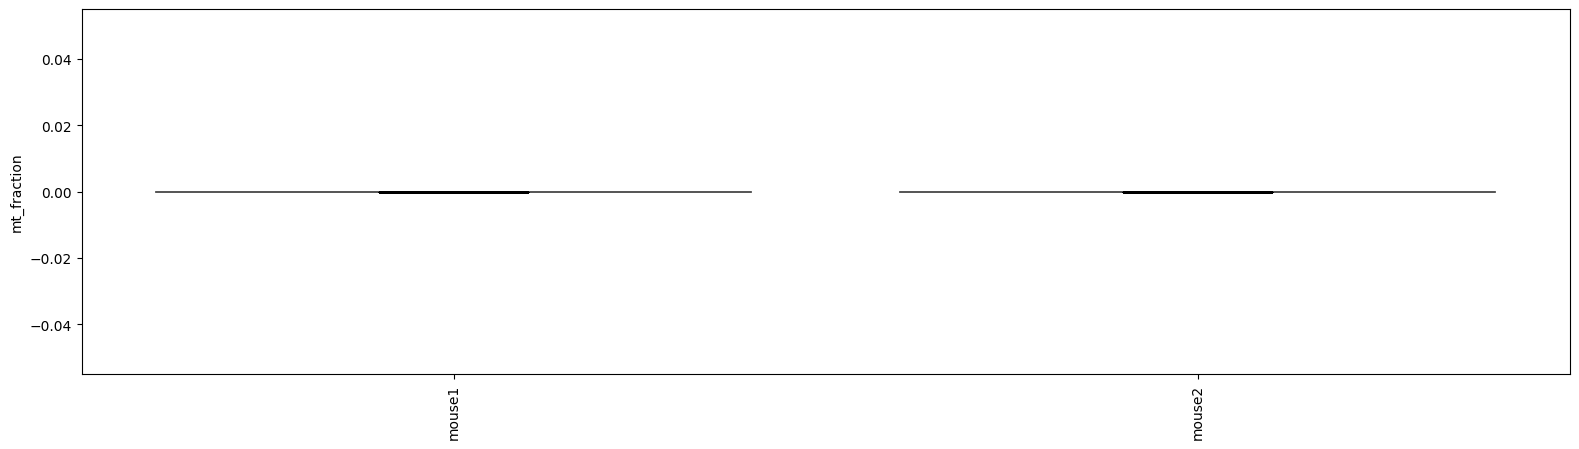

In [7]:
rcParams['figure.figsize'] = (15, 5)
sc.pl.violin(adata, ['log_counts'], groupby='mouse_id', size=1, log=False, rotation=90)
sc.pl.violin(adata, ['n_genes'], groupby='mouse_id', size=1, log=False, rotation=90)
sc.pl.violin(adata, ['mt_fraction'], groupby='mouse_id', size=1, log=False, rotation=90)

<Axes: title={'center': 'mt fraction'}, xlabel='n_counts', ylabel='n_genes'>

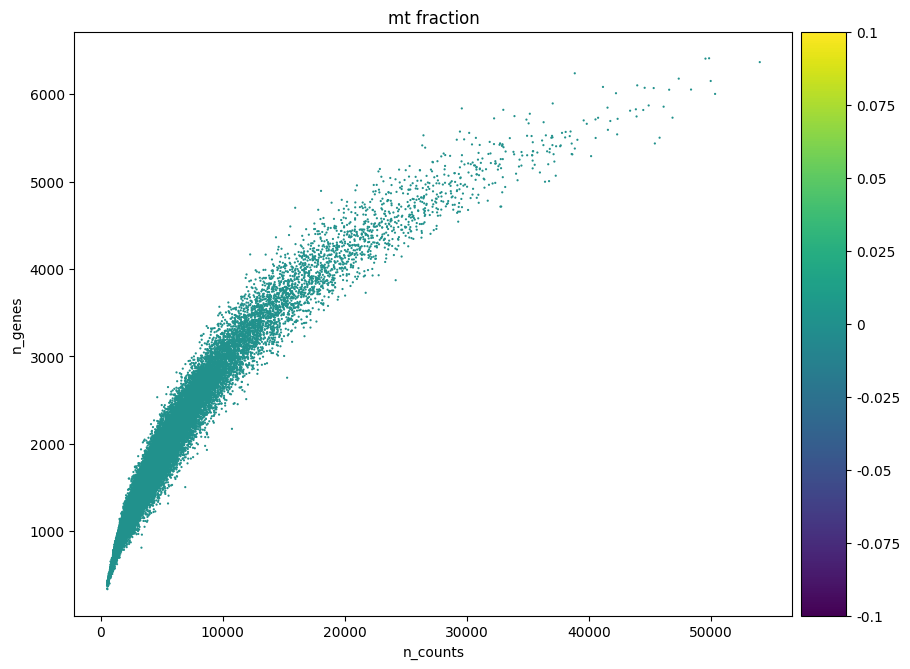

In [8]:
rcParams['figure.figsize'] = (8, 8)
sc.pl.scatter(adata, y='n_genes', x='n_counts', color='mt_fraction', size=10, show=False)

In [9]:
adata_tmp = adata.copy()
print(f'Total number of cells: {adata_tmp.n_obs}')
high_mt = adata_tmp.obs['mt_fraction'] < 0.2  #todo why this value
adata_tmp = adata_tmp[high_mt]
print(f'Number of cells after MT filter: {adata_tmp.n_obs}')

Total number of cells: 39845
Number of cells after MT filter: 39845


In [10]:
low_count = adata_tmp.obs['n_counts'] > 1000
adata_tmp = adata_tmp[low_count]
print(f'Number of cells after minimum count filter: {adata_tmp.n_obs}')

sc.pp.filter_cells(adata_tmp, max_counts=10000)
print(f'Number of cells after maximum filter: {adata_tmp.n_obs}')

Number of cells after minimum count filter: 39389


e:\Anaconda\envs\mvTCR\lib\site-packages\scanpy\preprocessing\_simple.py:137: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_counts'] = number


Number of cells after maximum filter: 35835


In [11]:
low_genes = adata_tmp.obs['n_genes'] > 500
adata_tmp = adata_tmp[low_genes]
print(f'Number of cells after minimum gene filter: {adata_tmp.n_obs}')

Number of cells after minimum gene filter: 35835


In [12]:
sc.pp.filter_genes(adata_tmp, min_cells=10)
print(f'Number of cells after gene filter: {adata_tmp.n_vars}')

e:\Anaconda\envs\mvTCR\lib\site-packages\scanpy\preprocessing\_simple.py:250: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var['n_cells'] = number


Number of cells after gene filter: 14358


In [13]:
import scrublet as scr
import scipy.io
import time

In [14]:
adata_tmp.obs['doublet_score'] = np.zeros(adata_tmp.shape[0])
adata_tmp.obs['doublet'] = np.zeros(adata_tmp.shape[0])

In [15]:
# filtering / preprocessing parameters:
min_counts = 2
min_cells = 3
vscore_percentile = 85
n_pc = 50

# doublet detector parameters
expected_doublet_rate = 0.02
sim_doublet_ratio = 3
n_neighbors = 15

for batch in enumerate(adata_tmp.obs['mouse_id'].cat.categories):
    print(batch)
    t0 = time.time()
    idx = np.flatnonzero(adata_tmp.obs['mouse_id']==batch[1])
    scrub = scr.Scrublet(counts_matrix = adata_tmp[idx, :].X,
                        n_neighbors = n_neighbors,
                        sim_doublet_ratio = sim_doublet_ratio,
                        expected_doublet_rate = expected_doublet_rate)
    doublet_scores, predicted_doublets = scrub.scrub_doublets(min_counts = min_counts,
                                                              min_cells = min_cells,
                                                              n_prin_comps = n_pc,
                                                              use_approx_neighbors = True,
                                                              get_doublet_neighbor_parents = False)
    adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores
    adata_tmp.obs['doublet'].iloc[idx] = predicted_doublets
    t1 = time.time()
    print('Elapsed time: {:.1f} seconds'.format(t1-t0))

(0, 'mouse1')
Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.14
Detected doublet rate = 1.0%
Estimated detectable doublet fraction = 23.8%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 4.0%
Elapsed time: 14.8 seconds
Elapsed time: 15.3 seconds
(1, 'mouse2')


C:\Users\a4945\AppData\Local\Temp\ipykernel_37052\3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores
C:\Users\a4945\AppData\Local\Temp\ipykernel_37052\3502024312.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet'].iloc[idx] = predicted_doublets


Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.14
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 32.8%
Overall doublet rate:
	Expected   = 2.0%
	Estimated  = 1.5%
Elapsed time: 13.1 seconds
Elapsed time: 13.5 seconds


C:\Users\a4945\AppData\Local\Temp\ipykernel_37052\3502024312.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adata_tmp.obs['doublet_score'].iloc[idx] = doublet_scores


In [16]:
sc.pp.normalize_total(adata_tmp, target_sum=1e4)
sc.pp.log1p(adata_tmp)

In [34]:
adata_tmp

AnnData object with n_obs × n_vars = 35835 × 14358
    obs: 'batch', 'condition', 'mouse_id', 'assignment_demuxem', 'n_counts', 'log_counts', 'n_genes', 'mt_fraction', 'doublet_score', 'doublet', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size'
    var: 'n_cells'
    uns: 'mouse_id_colors', 'log1p', 'chain_indices', 'ir_dist_nt_identity', 'clone_id'
    obsm: 'airr', 'chain_indices'

In [24]:
adata

View of AnnData object with n_obs × n_vars = 32359 × 27998
    obs: 'batch', 'condition', 'mouse_id', 'assignment_demuxem', 'n_counts', 'log_counts', 'n_genes', 'mt_fraction', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size'
    uns: 'mouse_id_colors', 'chain_indices', 'ir_dist_nt_identity', 'clone_id'
    obsm: 'airr', 'chain_indices'

In [25]:
adata =  adata_tmp
ir.pp.index_chains(adata)
ir.tl.chain_qc(adata)

# by nucleotide acid seq
ir.pp.ir_dist(adata)
ir.tl.define_clonotypes(adata, receptor_arms="all", dual_ir="primary_only")

100%|██████████| 13969/13969 [00:08<00:00, 1567.27it/s]


In [26]:
junction_aa = ir.get.airr(adata, "junction_aa")
cells_with_both_chains = ~(junction_aa['VJ_1_junction_aa'].isna() | junction_aa['VDJ_1_junction_aa'].isna())
print(adata.shape)
adata = adata[cells_with_both_chains]
print(adata.shape)

(35835, 14358)
(28652, 14358)


In [27]:
from mvtcr.utils_preprocessing import Preprocessing

In [28]:
# Preprocessing.check_if_valid_adata(adata)

In [29]:
Preprocessing.encode_clonotypes(adata)

100%|██████████| 10791/10791 [00:07<00:00, 1478.21it/s]


In [30]:
Preprocessing.encode_tcr(adata, airr_name='junction_aa', 
               alpha_label_key='alpha_seq', alpha_length_key='alpha_len',
               beta_label_key='beta_seq', beta_length_key='beta_len')

In [32]:
adata

AnnData object with n_obs × n_vars = 28652 × 14358
    obs: 'batch', 'condition', 'mouse_id', 'assignment_demuxem', 'n_counts', 'log_counts', 'n_genes', 'mt_fraction', 'doublet_score', 'doublet', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonotype', 'clonotype_size', 'alpha_len', 'beta_len'
    var: 'n_cells'
    uns: 'mouse_id_colors', 'log1p', 'chain_indices', 'ir_dist_nt_identity', 'clone_id', 'clonotype', 'aa_to_id'
    obsm: 'airr', 'chain_indices', 'alpha_seq', 'beta_seq'

In [37]:
adata.obs['doublet'] = adata.obs['doublet'].astype('category')

In [42]:
adata.write('10x_processed.h5ad')